# PS2 — AI advice, human trust, and first-price bidding

Reproduces every number in the paper. Run all cells top to bottom (Colab: *Runtime → Run all*).

**Game.** Two buyers, one second-hand item worth 6 to each (units of 10 RMB), budget 5 each.
Each bids Low 2 or High 5; highest bid wins and pays its own bid; ties split 50/50.
**Conditions.** No AI · buyer-aligned AI · seller-aligned AI (sponsor disclosed).
**Behavior model.** A buyer follows advice with probability *trust*; otherwise bids High with
probability `BASELINE_HIGH` (an assumption until the No-AI peer-play data replace it).

In [1]:
# Colab only: fetch the repository if the code is not already here
import os, sys
REPO_URL = "https://github.com/<your-team>/ps2-ai-advice-auction"  # TODO: replace
if not os.path.exists("src") and not os.path.exists("../src"):
    os.system(f"git clone {REPO_URL} repo && cp -r repo/* .")
sys.path.insert(0, ".."); sys.path.insert(0, ".")

In [2]:
from src.auction import (MAIN, SECOND_PRICE, payoff_matrix_str, game_summary,
                         trust_threshold, trust_sweep, expected_outcomes, simulate, ai_advice, CONDITIONS)
BASELINE_HIGH, SEED = 0.25, 42
payoff_matrix_str(MAIN)

,Low 2,High 5
Buyer 1 / Buyer 2,,
Low 2,"(7, 7)","(5, 6)"
High 5,"(6, 5)","(5.5, 5.5)"


## 1. Q1 — equilibrium benchmark (first price)

In [3]:
game_summary(MAIN)

{'rule': 'first',
 'high_bid': 5.0,
 'pure_nash': [('Low', 'Low'), ('High', 'High')],
 'dominant': None,
 'mixed_p_star': 0.6666666666666666,
 'risk_dominant': 'Low',
 'buyer_ai_advice': 'Low',
 'seller_ai_advice': 'High'}

Two pure equilibria: (Low, Low) and (High, High). Low is also risk-dominant.
High is the better reply only if the other buyer bids High with probability above p* = 2/3.
Total welfare is constant (2 × budget + value = 16): advice only moves money between buyers and seller.

## 2. Mechanism comparison — second price

In [4]:
display(payoff_matrix_str(SECOND_PRICE)); game_summary(SECOND_PRICE)

,Low 2,High 5
Buyer 1 / Buyer 2,,
Low 2,"(7, 7)","(5, 9)"
High 5,"(9, 5)","(5.5, 5.5)"


{'rule': 'second',
 'high_bid': 5.0,
 'pure_nash': [('High', 'High')],
 'dominant': 'High',
 'mixed_p_star': None,
 'risk_dominant': None,
 'buyer_ai_advice': 'Low',
 'seller_ai_advice': 'High'}

## 3. Q2 — AI advice and the trust threshold

In [5]:
print({c: ai_advice(MAIN, s) for c, s in CONDITIONS.items()})
print("t* =", round(trust_threshold(MAIN, BASELINE_HIGH), 4))

{'No AI': None, 'Buyer-aligned AI': 'Low', 'Seller-aligned AI': 'High'}
t* = 0.5556


In [6]:
import pandas as pd
rows = []
for c, s in CONDITIONS.items():
    for t in (0.0, 0.5, 1.0):
        r = expected_outcomes(MAIN, ai_advice(MAIN, s), t, BASELINE_HIGH)
        rows.append({"condition": c, "trust": t, **{k: round(v, 3) for k, v in r.items()}})
pd.DataFrame(rows)

,condition,trust,share_high,p_LL,p_HH,buyer_payoff,revenue,welfare
0,No AI,0.0,0.250,0.562,0.062,6.344,3.312,16.0
1,No AI,0.5,0.250,0.562,0.062,6.344,3.312,16.0
2,No AI,1.0,0.250,0.562,0.062,6.344,3.312,16.0
3,Buyer-aligned AI,0.0,0.250,0.562,0.062,6.344,3.312,16.0
4,Buyer-aligned AI,0.5,0.125,0.766,0.016,6.648,2.703,16.0
5,Buyer-aligned AI,1.0,0.000,1.000,0.000,7.000,2.000,16.0
6,Seller-aligned AI,0.0,0.250,0.562,0.062,6.344,3.312,16.0
7,Seller-aligned AI,0.5,0.625,0.141,0.391,5.711,4.578,16.0
8,Seller-aligned AI,1.0,1.000,0.000,1.000,5.500,5.000,16.0


In [7]:
# Monte Carlo check of the exact formulas (trust 0.5)
for c, s in CONDITIONS.items():
    a = ai_advice(MAIN, s)
    print(c, round(expected_outcomes(MAIN, a, .5, BASELINE_HIGH)["revenue"], 3),
          round(simulate(MAIN, a, .5, BASELINE_HIGH, seed=SEED)["revenue"], 3))

No AI 3.312 3.323
Buyer-aligned AI 2.703 2.696
Seller-aligned AI 4.578 4.584


## 4. Figure

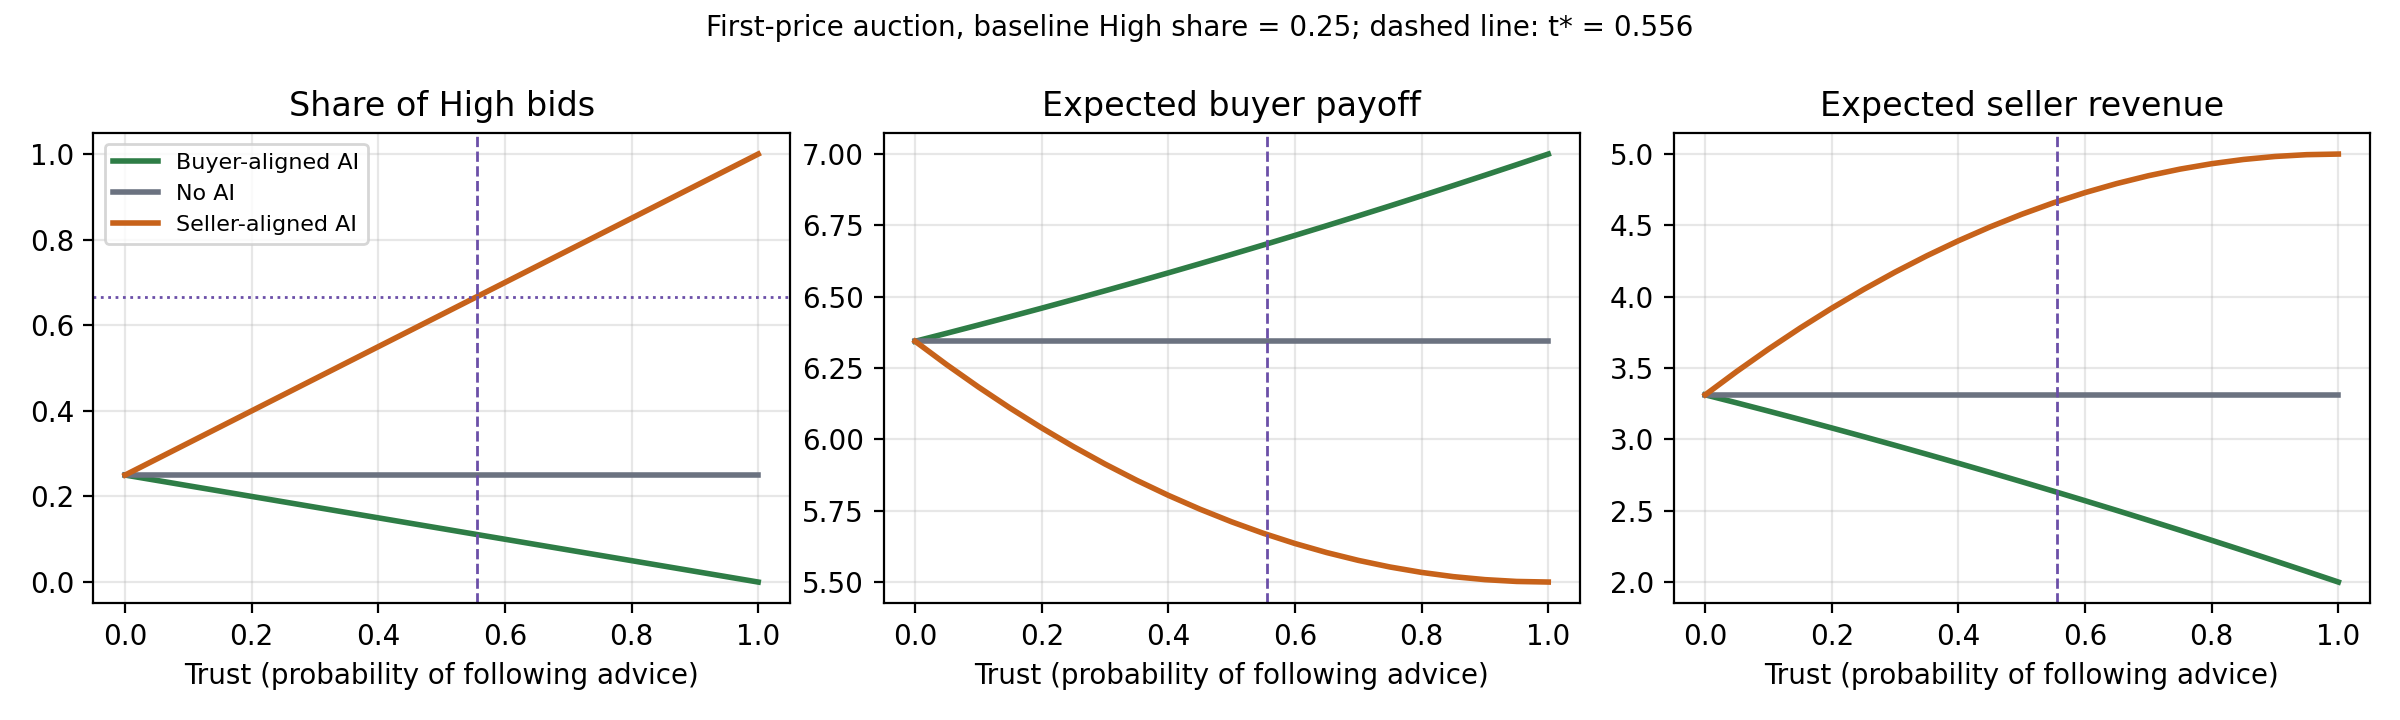

In [8]:
import subprocess; subprocess.run([sys.executable, "run_all.py"] if os.path.exists("run_all.py")
                                     else [sys.executable, "../run_all.py"], cwd=".." if not os.path.exists("run_all.py") else ".",
                                     capture_output=True)
from IPython.display import Image
Image("../figures/trust_sweep.png" if os.path.exists("../figures/trust_sweep.png") else "figures/trust_sweep.png")

## Limits
Common, known value (not private values); two bid levels; one-shot play; trust is a single
probability; `BASELINE_HIGH` is assumed. Classroom play is exploratory evidence only.